In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [69]:
data = pd.read_csv(r"D:\projects\stock_data.csv")
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

In [70]:
data['SMA_20'] = data['Close'].rolling(window=20).mean()

In [71]:
data['EMA_50'] = data['Close'].ewm(span=50, adjust=False).mean()

In [72]:
delta = data['Close'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
data['RSI_14'] = 100 - (100 / (1 + rs))

In [73]:
ema_12 = data['Close'].ewm(span=12, adjust=False).mean()
ema_26 = data['Close'].ewm(span=26, adjust=False).mean()
data['MACD'] = ema_12 - ema_26

In [74]:
data.fillna(method='bfill', inplace=True)

C:\Users\Sunilraj\AppData\Local\Temp\ipykernel_9844\67549027.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='bfill', inplace=True)


In [75]:
features = ['Close', 'SMA_20', 'EMA_50', 'RSI_14', 'MACD']
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data[features])

def create_dataset(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i,0])  # predict Close
    return np.array(X), np.array(y)

window_size = 60
X, y = create_dataset(scaled_data, window_size)
X = X.reshape(X.shape[0], X.shape[1], X.shape[2])

In [76]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [77]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

c:\Users\Sunilraj\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [78]:
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0054 - val_loss: 8.2500e-04
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 2.9543e-04 - val_loss: 9.0577e-04
Epoch 3/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - loss: 2.3885e-04 - val_loss: 5.0736e-04
Epoch 4/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 2.3301e-04 - val_loss: 5.1153e-04
Epoch 5/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - loss: 2.0016e-04 - val_loss: 3.8387e-04
Epoch 6/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - loss: 2.0677e-04 - val_loss: 9.8806e-04
Epoch 7/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 2.2689e-04 - val_loss: 3.3678e-04
Epoch 8/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 1.9120e-04 - val_loss: 5.3928e-04
Epoch 9/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 1.8131e-04 - val_loss: 5.5349e-04
Epoch 10/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 1.8412e-04 - val_loss: 2.9217e-04
Epoch 11/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 1.9881e-04 - 

In [79]:
predictions = model.predict(X_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


In [80]:
close_scaler = MinMaxScaler()
close_scaler.min_, close_scaler.scale_ = scaler.min_[0], scaler.scale_[0]
predictions_rescaled = close_scaler.inverse_transform(predictions.reshape(-1,1))
y_test_rescaled = close_scaler.inverse_transform(y_test.reshape(-1,1))

In [81]:
mae = mean_absolute_error(y_test_rescaled, predictions_rescaled)
mse = mean_squared_error(y_test_rescaled, predictions_rescaled)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_rescaled, predictions_rescaled)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

MAE: 6.32
MSE: 64.89
RMSE: 8.06
R² Score: 0.88


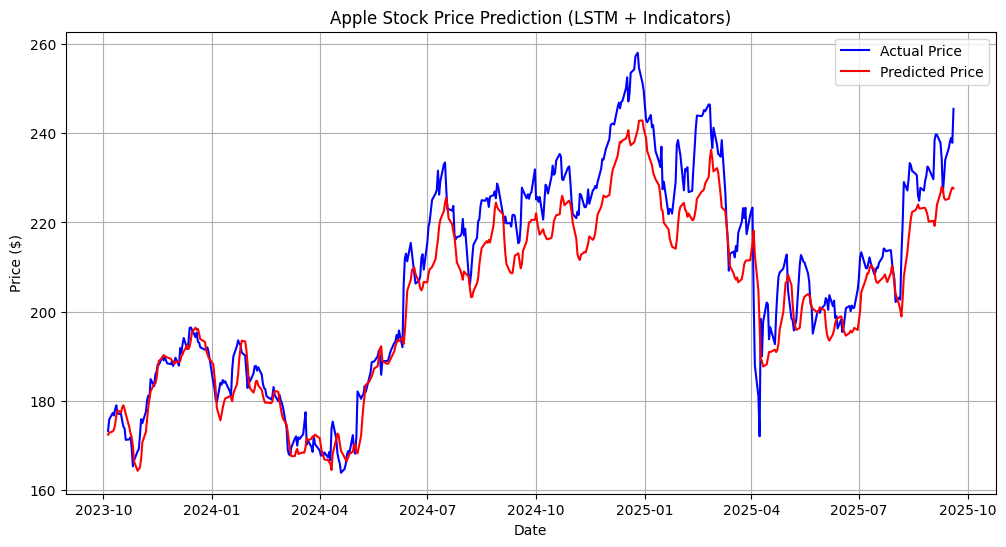

In [82]:
plt.figure(figsize=(12,6))
plt.plot(data.index[-len(y_test_rescaled):], y_test_rescaled, color='blue', label='Actual Price')
plt.plot(data.index[-len(y_test_rescaled):], predictions_rescaled, color='red', label='Predicted Price')
plt.title('Apple Stock Price Prediction (LSTM + Indicators)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()